# Sample script for plotting vertical profiles of observed variables

## Required packages
- numpy
- matplotlib

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from bsod2 import Sonde

## Read observational data and perform quality control.

In [2]:
# station name and sonde number mapping based on the field book.
# Note that the station name (e.g., "St.4a") is only for labeling the plot and is not used for QC.
# The sonde number is used to identify the corresponding data file.

field_book = {
        "St.4a": "1101771",
        "St.4b": "1101323",
        "St.4c": "1101386",
        "St.4d": "1101322",
        "St.4e": "1101327",
        "St.4f": "1101772",
        "St.4g": "1101388",
        "St.4h": "1101326",
    }

raw_data_dir = Path("Seisuimaru2407/raw_data")  # raw data directory

data = {}
for st_name, sonde_no in field_book.items():
    fpath = next(raw_data_dir.glob(f"F*S{sonde_no}.CSV"))
    data[st_name] = [Sonde(fpath,interp="z")]

# assign colors for each station for plotting.
for i,st_name in enumerate(data.keys()):
    data[st_name].append(plt.rcParams['axes.prop_cycle'].by_key()['color'][i])

## Plot vertical profiles

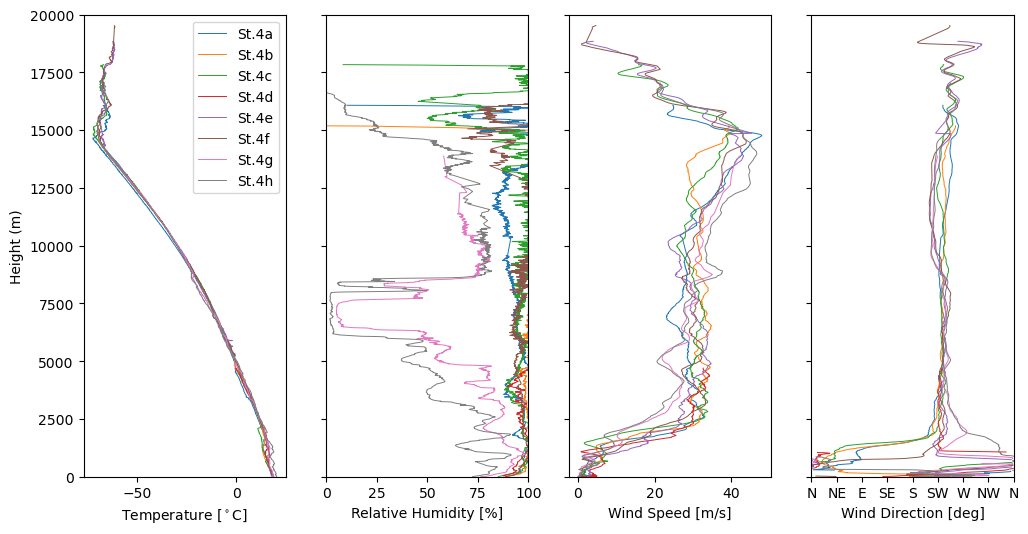

In [ ]:
ZMIN, ZMAX = 0, 2e4     # range of height to plot

fig,axes = plt.subplots(1,4,sharey=True,figsize=(12,6))

axes[0].set_ylim(ZMIN, ZMAX)
axes[0].set_ylabel("Height (m)")

# temperature
axes[0].set_xlabel(r"Temperature [$^\circ$C]")
for st_name, [sonde, color] in data.items():
    axes[0].plot(sonde.t, sonde.z, label=st_name, lw=0.7, color=color)
    axes[0].legend(loc="upper right")

# relative humidity
axes[1].set_xlabel("Relative Humidity [%]")
axes[1].set_xlim(0, 100)
for st_name, [sonde, color] in data.items():
    axes[1].plot(sonde.rh, sonde.z, label=sonde.sonde_no, lw=0.7, color=color)

# WS
axes[2].set_xlabel("Wind Speed [m/s]")
for st_name, [sonde, color] in data.items():
    axes[2].plot(sonde.ws, sonde.z, label=sonde.sonde_no,lw=0.7, color=color)

# WD
axes[3].set_xlabel("Wind Direction [deg]")
axes[3].set_xlim(0, 360)
axes[3].set_xticks(np.arange(0, 361, 45))
axes[3].set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW", "N"])
for st_name, [sonde, color] in data.items():
    # split the WD at discontinuous points
    wd = sonde.wd.m.copy()
    z = sonde.z.m.copy()
    split_idx = np.where(np.abs(np.diff(wd)) > 90)[0]+1
    wd_split = np.split(wd, split_idx)
    z_split = np.split(z, split_idx)
    for wd_part, z_part in zip(wd_split, z_split):
        axes[3].plot(wd_part, z_part, label=st_name, lw=0.7, color=color)

plt.show()